# Budget Variance Analysis Automation

This notebook connects to the BigQuery analytical layer and automates
validation, management reporting, visualization, and output generation.

## 1. Setup & BigQuery Connection
Connect to Google BigQuery and initialize the required Python libraries.

In [1]:
from google.colab import auth
auth.authenticate_user()

In [2]:
from google.cloud import bigquery
import pandas as pd

project_id = "budget-variance-portfolio"

client = bigquery.Client(project=project_id)

## 2. Data Extraction
Load executive KPIs, driver analysis and Pareto results from the
BigQuery analytical views into pandas DataFrames.

In [3]:
def format_for_display(df, money_cols=None, pct_cols=None, int_cols=None):
    display_df = df.copy()

    money_cols = money_cols or []
    pct_cols = pct_cols or []
    int_cols = int_cols or []

    for col in money_cols:
        if col in display_df.columns:
            display_df[col] = (
                display_df[col]
                .astype(float)
                .map("{:,.0f}".format)
            )

    for col in pct_cols:
        if col in display_df.columns:
            display_df[col] = (
                display_df[col]
                .astype(float)
                .mul(100)
                .map("{:.2f}%".format)
            )

    for col in int_cols:
        if col in display_df.columns:
            display_df[col] = (
                display_df[col]
                .astype(float)
                .map("{:,.0f}".format)
            )

    return display_df

In [4]:
query = """
SELECT *
FROM `budget-variance-portfolio.budget_controlling.vw_driver_summary`
ORDER BY variance ASC
"""

driver_summary = client.query(query).to_dataframe()

driver_summary_display = format_for_display(
    driver_summary,
    money_cols=["variance", "avg_variance_per_transaction"],
    pct_cols=["issue_pct"],
    int_cols=["transactions"]
)

driver_summary_display

,department,category,variance,worst_region,worst_month,transactions,issue_pct,avg_variance_per_transaction
0,Marketing,Training,"-5,501,558",East,2021-04,280,66.43%,"-19,648"
1,Marketing,Travel,"-4,134,647",East,2022-08,274,59.49%,"-15,090"
2,Operations,Salaries,"-4,116,403",South,2021-03,258,58.14%,"-15,955"
3,Sales,Utilities,"-4,067,500",North,2022-09,289,58.13%,"-14,074"
4,Operations,Utilities,"-3,988,056",North,2023-05,305,58.69%,"-13,076"


In [5]:
kpi_query = """
SELECT *
FROM `budget-variance-portfolio.budget_controlling.vw_executive_kpis`
"""

kpis = client.query(kpi_query).to_dataframe()

kpis_display = format_for_display(
    kpis,
    money_cols=["total_budget", "total_actual", "total_variance"],
    pct_cols=["variance_pct", "budget_utilization", "issue_pct"],
    int_cols=["transactions", "issue_transactions"]
)

kpis_display

,total_budget,total_actual,total_variance,variance_pct,budget_utilization,transactions,issue_transactions,issue_pct
0,"796,111,159","891,202,705","-95,091,546",-11.94%,111.94%,"10,010","5,598",55.92%


In [6]:
pareto_query = """
SELECT *
FROM `budget-variance-portfolio.budget_controlling.vw_pareto_analysis`
ORDER BY driver_rank
"""

pareto = client.query(pareto_query).to_dataframe()

pareto_display = format_for_display(
    pareto.head(10),
    money_cols=["variance", "abs_variance"],
    pct_cols=["share_pct", "cumulative_pct"],
    int_cols=["driver_rank"]
)

pareto_display.head(10)

,driver_rank,department,category,variance,abs_variance,share_pct,cumulative_pct
0,1,Marketing,Training,"-5,501,558","5,501,558",5.79%,5.79%
1,2,Marketing,Travel,"-4,134,647","4,134,647",4.35%,10.13%
2,3,Operations,Salaries,"-4,116,403","4,116,403",4.33%,14.46%
3,4,Sales,Utilities,"-4,067,500","4,067,500",4.28%,18.74%
4,5,Operations,Utilities,"-3,988,056","3,988,056",4.19%,22.93%
5,6,IT,Salaries,"-3,974,415","3,974,415",4.18%,27.11%
6,7,HR,Training,"-3,699,628","3,699,628",3.89%,31.00%
7,8,Marketing,Marketing,"-3,638,120","3,638,120",3.83%,34.83%
8,9,Operations,Marketing,"-3,621,586","3,621,586",3.81%,38.64%
9,10,Marketing,Salaries,"-3,510,773","3,510,773",3.69%,42.33%


## 3. Data Validation
Validate key financial metrics against the previously reconciled
Google Sheets and SQL results.

In [7]:
expected = {
    "total_budget": 796_111_159,
    "total_actual": 891_202_705,
    "total_variance": -95_091_546
}

actual = kpis.iloc[0]

for metric, expected_value in expected.items():
    actual_value = actual[metric]
    status = "PASS" if round(actual_value, 2) == round(expected_value, 2) else "FAIL"
    print(f"{metric}: {actual_value:,.2f} | expected: {expected_value:,.2f} | {status}")

total_budget: 796,111,159.00 | expected: 796,111,159.00 | PASS
total_actual: 891,202,705.00 | expected: 891,202,705.00 | PASS
total_variance: -95,091,546.00 | expected: -95,091,546.00 | PASS


## 4. Driver Analysis
Identify the largest unfavorable variance driver and its main
regional and temporal characteristics.

In [8]:
top_driver = driver_summary.iloc[0]

print("Top driver:")
print(f"{top_driver['department']} × {top_driver['category']}")
print(f"Variance: {top_driver['variance']:,.0f}")
print(f"Worst region: {top_driver['worst_region']}")
print(f"Worst month: {top_driver['worst_month']}")

Top driver:
Marketing × Training
Variance: -5,501,558
Worst region: East
Worst month: 2021-04


## 5. Automated Visualizations
Generate management-level visualizations of the largest unfavorable
variance drivers and their cumulative contribution.

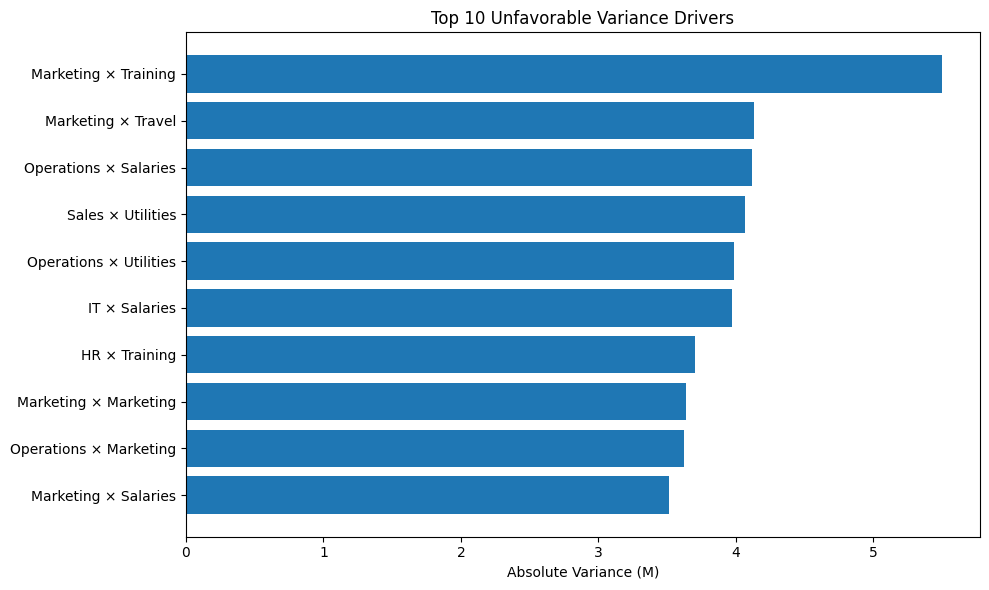

In [9]:
import matplotlib.pyplot as plt

top10 = pareto.head(10).copy()
top10["driver"] = top10["department"] + " × " + top10["category"]

plt.figure(figsize=(10, 6))

plt.barh(
    top10["driver"],
    top10["abs_variance"].astype(float) / 1_000_000
)

plt.title("Top 10 Unfavorable Variance Drivers")
plt.xlabel("Absolute Variance (M)")
plt.ylabel("")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

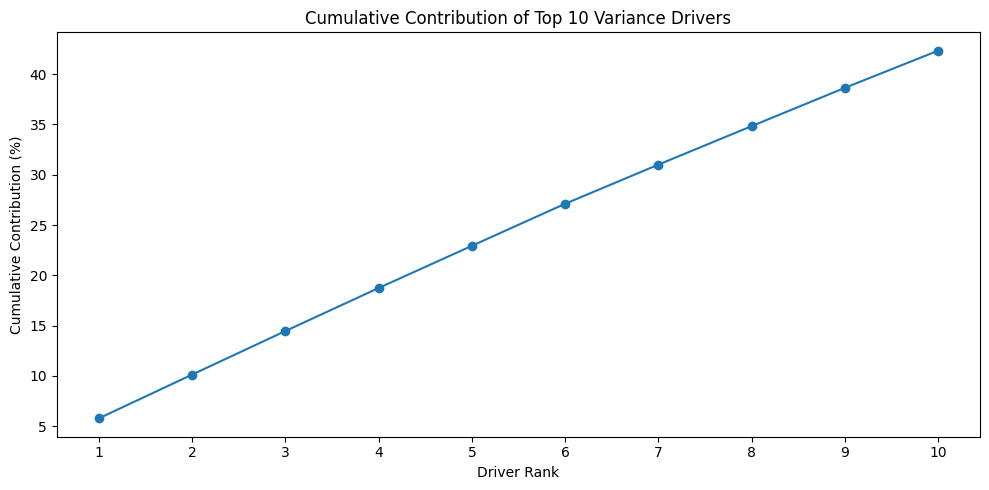

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    top10["driver_rank"],
    top10["cumulative_pct"].astype(float) * 100,
    marker="o"
)

plt.title("Cumulative Contribution of Top 10 Variance Drivers")
plt.xlabel("Driver Rank")
plt.ylabel("Cumulative Contribution (%)")

plt.xticks(top10["driver_rank"])

plt.tight_layout()
plt.show()

## 6. Management Summary
Automatically generate a management narrative based on the latest
analytical results.

In [11]:
overall = kpis.iloc[0]
top_driver = driver_summary.iloc[0]
top10_concentration = pareto.head(10)["share_pct"].sum()

management_summary = f"""
Budget Performance Summary

Actual spending exceeded budget by {abs(overall['variance_pct']) * 100:.2f}%,
resulting in an unfavorable variance of {abs(overall['total_variance']) / 1_000_000:.1f}M.

The largest unfavorable driver was
{top_driver['department']} × {top_driver['category']},
with a variance of {top_driver['variance'] / 1_000_000:.2f}M.

The Top 10 unfavorable drivers accounted for
{top10_concentration * 100:.2f}% of total unfavorable variance,
indicating that the overspend was distributed across multiple cost drivers.

For the largest driver, the worst-performing region was
{top_driver['worst_region']}, while the worst month was
{top_driver['worst_month']}.
"""

print(management_summary)


Budget Performance Summary

Actual spending exceeded budget by 11.94%,
resulting in an unfavorable variance of 95.1M.

The largest unfavorable driver was
Marketing × Training,
with a variance of -5.50M.

The Top 10 unfavorable drivers accounted for
42.33% of total unfavorable variance,
indicating that the overspend was distributed across multiple cost drivers.

For the largest driver, the worst-performing region was
East, while the worst month was
2021-04.



## 7. Export
Export the main analytical outputs for downstream reporting or further analysis.

In [12]:
kpis.to_csv("executive_kpis.csv", index=False)
driver_summary.to_csv("driver_summary.csv", index=False)
pareto.to_csv("pareto_analysis.csv", index=False)

with open("management_summary.txt", "w") as file:
    file.write(management_summary)

print("Files exported successfully.")

Files exported successfully.
